In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks',
    '/home/export/soheuny/SRFinder/soheun/notebooks/draft'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("/home/export/soheuny/SRFinder/soheun")

In [2]:
from typing import Tuple, Any
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut
from events_data import events_from_scdinfo
from dataset import MotherSamples
from training_info import TrainingInfo

SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3
# legend font size
plt.rcParams["legend.fontsize"] = 15

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
from matplotlib.colors import LogNorm
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut

# Constants
NBINS = 30
SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_training_info(experiment_name: str, signal_ratio: float, seed: int, allowed_noise_scales: List[float]) -> List[str]:
    """Find training info hashes based on experiment parameters."""
    hashes = TrainingInfo.find({
        "experiment_name": experiment_name, 
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
        "signal_region": lambda x: x["4b_in_SR"] == 0.2
    })
    noise_scales = get_noise_scales(hashes)
    return [hash_ for hash_, noise_scale in zip(hashes, noise_scales) if noise_scale in allowed_noise_scales]

def get_noise_scales(hashes: List[str]) -> List[float]:
    """Extract noise scales from training info hashes."""
    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
    return noise_scales

def sort_hashes_by_noise_scale(hashes: List[str], noise_scales: List[float]) -> List[str]:
    """Sort hashes by their corresponding noise scales."""
    return [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

In [5]:
def get_cdf(x_values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """Get the cumulative distribution function of x_values with weights."""
    sorted_indices = np.argsort(x_values, kind="stable")
    sorted_x_values = x_values[sorted_indices]
    sorted_weights = weights[sorted_indices]
    cumsum_weights = np.cumsum(sorted_weights)
    return sorted_x_values, cumsum_weights / cumsum_weights[-1]

def plot_hash_results(hash_: str, 
                    events_train: EventsData,
                    events_tst: EventsData, 
                    axs: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    
    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, {"4b_in_SR": 0.2, "4b_in_CR": 0.8}
    )
    SR_idx = SR_stats_tst > SR_cut
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
    fvt_scores_train = base_tinfo.aux_info["base_fvt_logit_train"]
    fvt_scores_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
    fvt_scores_train = 1 / (1 + np.exp(-fvt_scores_train))
    fvt_scores_tst = 1 / (1 + np.exp(-fvt_scores_tst))
    
    bins_x = np.linspace(np.quantile(fvt_scores_tst, 0.005), np.quantile(fvt_scores_tst, 0.999), NBINS)
    bins_y = np.linspace(np.quantile(SR_stats_tst, 0.005), np.quantile(SR_stats_tst, 0.999), NBINS)
    
    axs[0, plot_idx].hist2d(fvt_scores_tst[events_tst.is_4b], SR_stats_tst[events_tst.is_4b], 
                                 bins=(bins_x, bins_y),
                                #  norm=LogNorm(),
                                 weights=events_tst.weights[events_tst.is_4b])
    axs[0, plot_idx].axhline(SR_cut, color="red", linestyle="--", label="SR Threshold")
    axs[0, plot_idx].legend(loc="upper left")
    
    axs[1, plot_idx].set_xlim(axs[0, plot_idx].get_xlim())
    axs[1, plot_idx].hist(fvt_scores_tst[SR_idx & events_tst.is_4b], bins=bins_x, 
                          histtype="step", label="SR", weights=events_tst.weights[SR_idx & events_tst.is_4b])
    axs[1, plot_idx].hist(fvt_scores_tst[(~SR_idx) & events_tst.is_4b], bins=bins_x, 
                          histtype="step", label="CR", weights=events_tst.weights[(~SR_idx) & events_tst.is_4b])
    axs[1, plot_idx].legend(loc="upper left")
    
    events_tst_SR = events_tst[SR_idx]
    
    SR_stats_tst_exp = np.exp(SR_stats_tst)
    
    bins_sr = np.linspace(SR_stats_tst_exp[SR_idx].min(), 
                          np.quantile(SR_stats_tst_exp[SR_idx], 0.999), 50)
    axs[2, plot_idx].hist(SR_stats_tst_exp[SR_idx & events_tst.is_bg4b], bins=bins_sr, 
                          histtype="step", label="Background", 
                          weights=events_tst.weights[SR_idx & events_tst.is_bg4b], 
                          color=plt.cm.tab10(1),
                          density=True)
    axs[2, plot_idx].hist(SR_stats_tst_exp[SR_idx & events_tst.is_signal], bins=bins_sr, 
                          histtype="step", label="Signal",
                          weights=events_tst.weights[SR_idx & events_tst.is_signal], 
                          color=plt.cm.tab10(2),
                          density=True)
    axs[2, plot_idx].legend(loc="upper right")
    
    
    sr_stats_4b = SR_stats_tst_exp[SR_idx & events_tst.is_4b]
    weights_4b = events_tst.weights[SR_idx & events_tst.is_4b]
    sr_stats_bg4b = SR_stats_tst_exp[SR_idx & events_tst.is_bg4b]
    weights_bg4b = events_tst.weights[SR_idx & events_tst.is_bg4b]
    
    sorted_sr_stats_4b, cdf_4b = get_cdf(sr_stats_4b, weights_4b)
    sorted_sr_stats_bg4b, cdf_bg4b = get_cdf(sr_stats_bg4b, weights_bg4b)
    
    eval_points = np.linspace(sorted_sr_stats_bg4b.min(), sorted_sr_stats_bg4b.max(), 1000)
    cdf_bg4b_eval = np.interp(eval_points, sorted_sr_stats_bg4b, cdf_bg4b)
    cdf_4b_eval = np.interp(eval_points, sorted_sr_stats_4b, cdf_4b)
    
    axs[3, plot_idx].plot(eval_points, cdf_bg4b_eval - cdf_4b_eval, label="CDF difference")
    axs[3, plot_idx].set_xlim(axs[2, plot_idx].get_xlim())
    axs[3, plot_idx].set_ylim(0, 0.025)
    axs[3, plot_idx].legend(loc="upper right")

In [ ]:
import matplotlib.gridspec as gridspec

SIGNAL_RATIO = 0.01
allowed_noise_scales = [0.1, 2.0, np.inf]

plt.rcParams["axes.labelsize"] = 30
plt.rcParams["axes.titlesize"] = 30
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["axes.titlepad"] = 10
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20

for seed in [0, 5, 10, 15]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    hashes = hashes[::-1]
    noise_scales = noise_scales[::-1]
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]

    fig = plt.figure(figsize=(6 * len(allowed_noise_scales), 12))  

    # Build a GridSpec with 4 rows and len(allowed_noise_scales) columns
    gs = gridspec.GridSpec(
        4, len(allowed_noise_scales), 
        height_ratios=[2, 1, 1, 1],  # 2:1:2:1 row ratio
        figure=fig
    )

    axs = np.empty((4, len(allowed_noise_scales)), dtype=object)
    for i in range(4):
        for j in range(len(allowed_noise_scales)):
            axs[i, j] = fig.add_subplot(gs[i, j])
    
    
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        noise_scale = get_noise_scales([hash_])[0]
        plot_hash_results(hash_, events_train, events_tst, axs, i)
        title = rf"$\eta = {noise_scale}$" if noise_scale != np.inf else r"$\eta = \infty$"
        axs[0, i].set_title(title)
        
    axs[0, 0].set_ylabel(r"$\hat{\psi}$")
    axs[1, 0].set_ylabel("Frequency")
    axs[2, 0].set_ylabel("Density")
    axs[3, 0].set_ylabel("CDF difference")
    
    axs[0, 1].set_xlabel(r"$\hat{\gamma}$")
    axs[1, 1].set_xlabel(r"$\hat{\gamma}$")
    axs[2, 1].set_xlabel(r"$\hat{\psi}$")
    axs[3, 1].set_xlabel(r"$\hat{\psi}$")
    
    # Display results
    fig.tight_layout()
    plt.savefig(f"./figures/how_smearing_works_signal_ratio_{SIGNAL_RATIO}_seed_{seed}.pdf", dpi=300)
    plt.show()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcb88dbbed0>>
Traceback (most recent call last):
  File "/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Processing hash 1/3
Processing hash 2/3


In [6]:
def plot_hash_results_v2(hash_: str, 
                    events_train: EventsData,
                    events_tst: EventsData, 
                    axs: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    
    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, {"4b_in_SR": 0.2, "4b_in_CR": 0.8}
    )
    SR_idx = SR_stats_tst > SR_cut
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
    fvt_scores_train = base_tinfo.aux_info["base_fvt_logit_train"]
    fvt_scores_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
    fvt_scores_train = np.exp(fvt_scores_train)
    fvt_scores_tst = np.exp(fvt_scores_tst)
    SR_stats_tst_exp = np.exp(SR_stats_tst)
    
    bins_x = np.linspace(np.quantile(fvt_scores_tst, 0.005), np.quantile(fvt_scores_tst, 0.999), NBINS)
    bins_y = np.linspace(np.quantile(SR_stats_tst_exp, 0.005), np.quantile(SR_stats_tst_exp, 0.999), NBINS)
    
    axs[0, plot_idx].hist2d(fvt_scores_tst[events_tst.is_4b], SR_stats_tst_exp[events_tst.is_4b], 
                                 bins=(bins_x, bins_y),
                                #  norm=LogNorm(),
                                 weights=events_tst.weights[events_tst.is_4b])
    axs[0, plot_idx].axhline(np.exp(SR_cut), color="red", linestyle="--", label="SR Threshold")
    axs[0, plot_idx].legend(loc="upper left")
    
    axs[1, plot_idx].set_xlim(axs[0, plot_idx].get_xlim())
    axs[1, plot_idx].hist(fvt_scores_tst[SR_idx & events_tst.is_4b], bins=bins_x, 
                          histtype="step", label="SR", weights=events_tst.weights[SR_idx & events_tst.is_4b], 
                          color=plt.cm.tab10(2))
    axs[1, plot_idx].hist(fvt_scores_tst[(~SR_idx) & events_tst.is_4b], bins=bins_x, 
                          histtype="step", label="CR", weights=events_tst.weights[(~SR_idx) & events_tst.is_4b], 
                          color=plt.cm.tab10(0))
    axs[1, plot_idx].legend(loc="upper left")

Processing hash 1/3
Processing hash 2/3
Processing hash 3/3


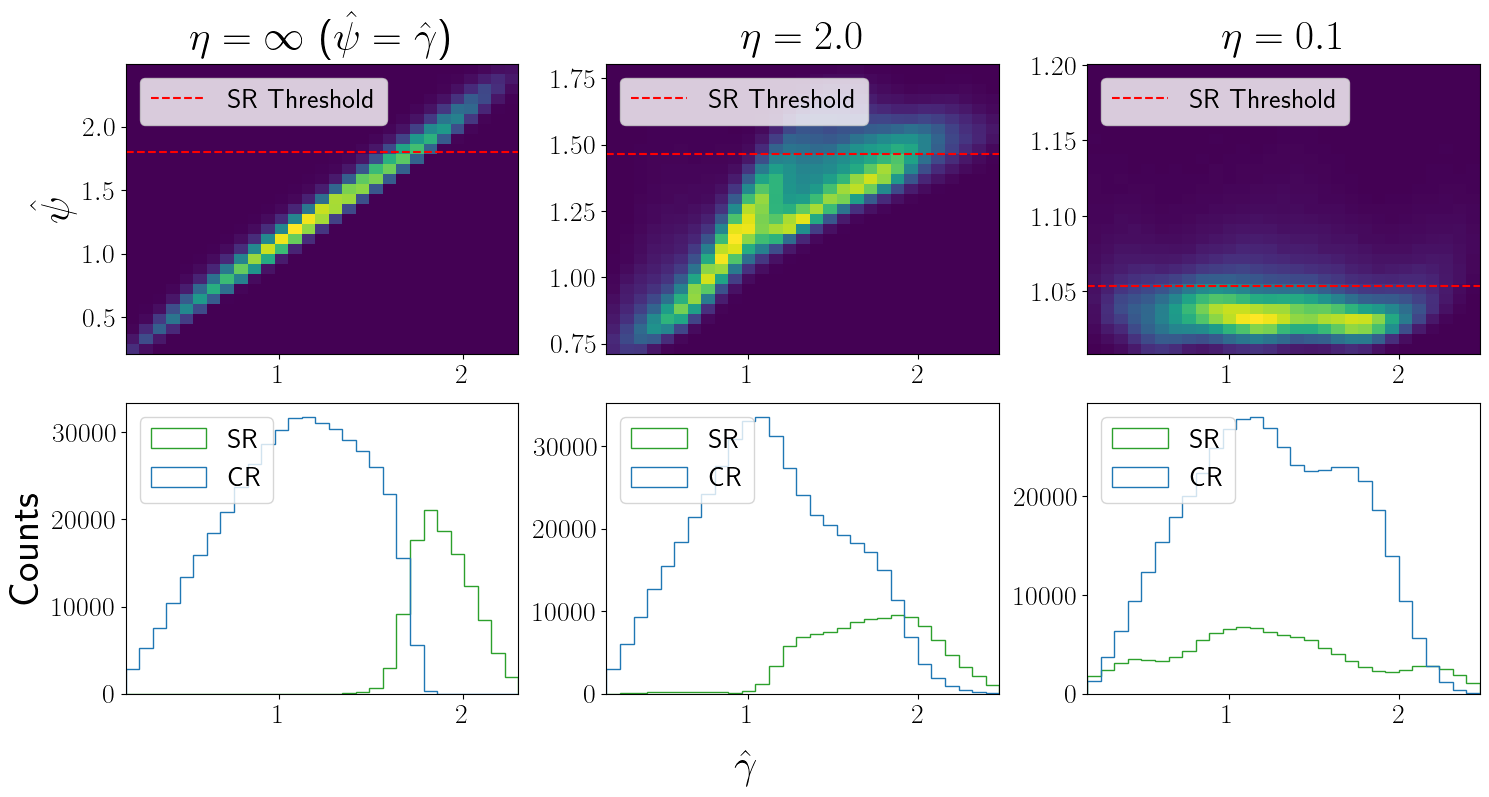

In [7]:
import matplotlib.gridspec as gridspec

SIGNAL_RATIO = 0.0
NBINS = 30
allowed_noise_scales = [np.inf, 2.0, 0.1]

plt.rcParams["axes.labelsize"] = 30
plt.rcParams["axes.titlesize"] = 30
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["axes.titlepad"] = 10
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["figure.labelsize"] = 30

for seed in [5]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    hashes = hashes[::-1]
    noise_scales = noise_scales[::-1]
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]

    fig = plt.figure(figsize=(5 * len(allowed_noise_scales), 8))  

    # Build a GridSpec with 4 rows and len(allowed_noise_scales) columns
    gs = gridspec.GridSpec(
        2, len(allowed_noise_scales), 
        height_ratios=[1, 1],  # 2:1:2:1 row ratio
        figure=fig
    )

    axs = np.empty((2, len(allowed_noise_scales)), dtype=object)
    for i in range(2):
        for j in range(len(allowed_noise_scales)):
            axs[i, j] = fig.add_subplot(gs[i, j])
    
    
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        noise_scale = get_noise_scales([hash_])[0]
        plot_hash_results_v2(hash_, events_train, events_tst, axs, i)
        title = rf"$\eta = {noise_scale}$" if noise_scale != np.inf else r"$\eta = \infty$ ($\hat\psi = \hat\gamma$)"
        axs[0, i].set_title(title)
        
    axs[0, 0].set_ylabel(r"$\hat{\psi}$")
    axs[1, 0].set_ylabel("Counts")
    fig.supxlabel(r"$\hat{\gamma}$")
    
    # Display results
    fig.tight_layout()
    plt.savefig(f"./figures/smearing_overlap_signal_ratio_{SIGNAL_RATIO}_seed_{seed}.pdf", dpi=300)
    plt.show()

Processing hash 1/3


/tmp/ipykernel_3979885/400769040.py:88: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/3
Processing hash 3/3


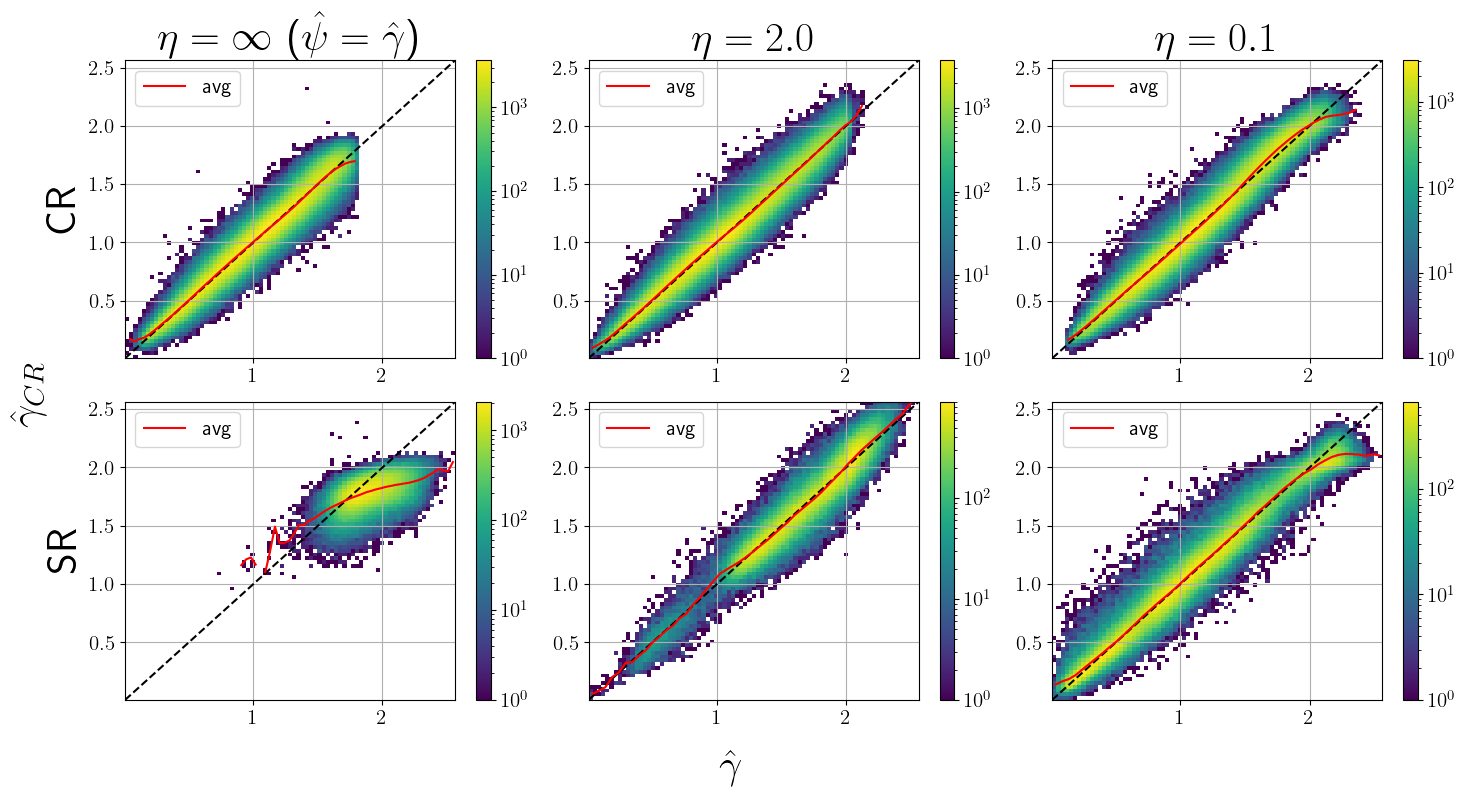

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
from matplotlib.colors import LogNorm
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut

# Constants
NBINS = 10
SIGNAL_RATIO = 0.0
SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_training_info(experiment_name: str, signal_ratio: float, seed: int, allowed_noise_scales: List[float]) -> List[str]:
    """Find training info hashes based on experiment parameters."""
    hashes = TrainingInfo.find({
        "experiment_name": experiment_name, 
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
        "signal_region": lambda x: x["4b_in_SR"] == 0.2
    })
    noise_scales = get_noise_scales(hashes)
    return [hash_ for hash_, noise_scale in zip(hashes, noise_scales) if noise_scale in allowed_noise_scales]

def get_noise_scales(hashes: List[str]) -> List[float]:
    """Extract noise scales from training info hashes."""
    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
    return noise_scales

def sort_hashes_by_noise_scale(hashes: List[str], noise_scales: List[float]) -> List[str]:
    """Sort hashes by their corresponding noise scales."""
    return [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

def calculate_base_fvt_scores(SR_stats_hashes: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate base FvT scores for training and test sets."""
    base_fvt_scores_tst = []
    base_fvt_scores_train = []
    
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        
        # Test scores
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        
        # Training scores
        base_fvt_logits_train = base_tinfo.aux_info["base_fvt_logit_train"]
        base_fvt_score_train = np.exp(base_fvt_logits_train)
        base_fvt_scores_train.append(base_fvt_score_train)
    
    return np.mean(base_fvt_scores_tst, axis=0), np.mean(base_fvt_scores_train, axis=0)


def compute_avg_fvt_score(base_fvt_scores: np.ndarray, fvt_scores: np.ndarray) -> np.ndarray:
    xmin = np.min(base_fvt_scores)
    xmax = np.max(base_fvt_scores)
    bins = np.linspace(xmin, xmax, 50)
    hist_fvt, _ = np.histogram(base_fvt_scores, bins)
    hist_fvt_wgt, _ = np.histogram(base_fvt_scores, bins, weights=fvt_scores)
    midpoints = (bins[1:] + bins[:-1]) / 2
    return midpoints, hist_fvt_wgt / hist_fvt

def hist_fvt_fvt(ax: plt.Axes, base_fvt_scores: np.ndarray, fvt_scores: np.ndarray, 
                 fvt_avg: np.ndarray, midpoints: np.ndarray, bins=None):
    # ax.set_xticks(np.arange(0, 1.1, 0.1))
    # ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    if bins is None:
        xmin = np.min(base_fvt_scores)
        xmax = np.max(base_fvt_scores)
        bins = np.linspace(xmin, xmax, 50)
    
    
    ax.plot([bins[0], bins[-1]], [bins[0], bins[-1]], color="black", linestyle="--")
    h = ax.hist2d(base_fvt_scores, fvt_scores, bins=(bins, bins), 
                  norm=LogNorm())
    plt.colorbar(h[3], ax=ax)
    ax.plot(midpoints, fvt_avg, color="red", label="avg")
    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)
    
def plot_hash_results_v3(hash_: str, 
                    base_fvt_scores_tst: np.ndarray, 
                    events_train: EventsData,
                    events_tst: EventsData, 
                    axs_hist: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    # Get region cuts and indices
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
    )
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    SR_idx = SR_stats_tst >= SR_cut
    
    # Calculate FVT scores
    events_tst_CR = events_tst[CR_idx]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()
    
    fvt_scores_tst_CR = fvt_scores_tst_CR / (1 - fvt_scores_tst_CR)
    fvt_scores_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    
    midpoints_cr, fvt_avg_cr = compute_avg_fvt_score(base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR)
    midpoints_sr, fvt_avg_sr = compute_avg_fvt_score(base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR)
    
    smearing_str = rf"$\eta = {noise_scale}$" if noise_scale != np.inf else r"$\eta = \infty$ ($\hat\psi = \hat\gamma$)"
    
    xmin = np.min(base_fvt_scores_tst)
    xmax = np.max(base_fvt_scores_tst)
    bins = np.linspace(xmin, xmax, 80)
    
    axs_hist[0, plot_idx].set_title(smearing_str, fontsize=30)
    hist_fvt_fvt(axs_hist[0, plot_idx], base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, fvt_avg_cr, midpoints_cr, bins)
    
    # axs_hist[1, plot_idx].set_title(f"SR with {smearing_str}")
    hist_fvt_fvt(axs_hist[1, plot_idx], base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, fvt_avg_sr, midpoints_sr, bins)
    
    for ax_hist in axs_hist[:, plot_idx]:
        ax_hist.legend()
    
    
allowed_noise_scales = [np.inf, 2.0, 0.1]
# for seed in range(0, 100, 5):
for seed in [5]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    hashes = hashes[::-1]
    noise_scales = noise_scales[::-1]
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    base_fvt_scores_tst, base_fvt_scores_train = calculate_base_fvt_scores([SR_stats_hashes[0]])

    
    fig_hist, axs_hist = plt.subplots(2, len(allowed_noise_scales), figsize=(5 * len(allowed_noise_scales), 8))
    fig_hist.supxlabel(r"$\hat{\gamma}$", fontsize=30)
    fig_hist.supylabel(r"$\hat{\gamma}_{CR}$", fontsize=30)
    
    # sort hashes by noise scale
    
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        plot_hash_results_v3(hash_, base_fvt_scores_tst, events_train, events_tst, axs_hist, i)
        
    axs_hist[0, 0].set_ylabel("CR", fontsize=30)
    axs_hist[1, 0].set_ylabel("SR", fontsize=30)
    
    fig_hist.tight_layout()
    plt.savefig(f"./figures/base_and_CR_fvt_scores_hist_seed_{seed}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [6]:
def plot_hash_results_v4(hash_: str, 
                    events_train: EventsData,
                    events_tst: EventsData, 
                    axs: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    
    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, {"4b_in_SR": 0.2, "4b_in_CR": 0.8}
    )
    SR_idx = SR_stats_tst > SR_cut
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
    fvt_scores_train = base_tinfo.aux_info["base_fvt_logit_train"]
    fvt_scores_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
    fvt_scores_train = np.exp(fvt_scores_train)
    fvt_scores_tst = np.exp(fvt_scores_tst)
    
    bins_x = np.linspace(np.quantile(fvt_scores_tst, 0.005), np.quantile(fvt_scores_tst, 0.999), NBINS)
    bins_y = np.linspace(np.quantile(SR_stats_tst, 0.005), np.quantile(SR_stats_tst, 0.999), NBINS)
    
    events_tst_SR = events_tst[SR_idx]
    SR_stats_tst_exp = np.exp(SR_stats_tst)
    
    bins_sr = np.linspace(SR_stats_tst_exp[SR_idx].min(), 
                          np.quantile(SR_stats_tst_exp[SR_idx], 0.999), 20)
    
    axs[0, plot_idx].hist(SR_stats_tst_exp[SR_idx & events_tst.is_bg4b], bins=bins_sr, 
                          histtype="step", label="Background", 
                          weights=events_tst.weights[SR_idx & events_tst.is_bg4b], 
                          color=plt.cm.tab10(1),
                          density=True)
    axs[0, plot_idx].hist(SR_stats_tst_exp[SR_idx & events_tst.is_signal], bins=bins_sr, 
                          histtype="step", label="Signal",
                          weights=events_tst.weights[SR_idx & events_tst.is_signal], 
                          color=plt.cm.tab10(2),
                          density=True)
    axs[0, plot_idx].legend(loc="upper right")
    
    hist_signal, _ = np.histogram(SR_stats_tst_exp[SR_idx & events_tst.is_signal], bins=bins_sr, 
                                  weights=events_tst.weights[SR_idx & events_tst.is_signal])
    hist_4b, _ = np.histogram(SR_stats_tst_exp[SR_idx & events_tst.is_4b], bins=bins_sr, 
                              weights=events_tst.weights[SR_idx & events_tst.is_4b])
    
    
    
    # sr_stats_4b = SR_stats_tst_exp[SR_idx & events_tst.is_4b]
    # weights_4b = events_tst.weights[SR_idx & events_tst.is_4b]
    # sr_stats_bg4b = SR_stats_tst_exp[SR_idx & events_tst.is_bg4b]
    # weights_bg4b = events_tst.weights[SR_idx & events_tst.is_bg4b]
    
    # sorted_sr_stats_4b, cdf_4b = get_cdf(sr_stats_4b, weights_4b)
    # sorted_sr_stats_bg4b, cdf_bg4b = get_cdf(sr_stats_bg4b, weights_bg4b)
    
    # eval_points = np.linspace(sorted_sr_stats_bg4b.min(), sorted_sr_stats_bg4b.max(), 1000)
    # cdf_bg4b_eval = np.interp(eval_points, sorted_sr_stats_bg4b, cdf_bg4b)
    # cdf_4b_eval = np.interp(eval_points, sorted_sr_stats_4b, cdf_4b)
    
    midpoints_sr = (bins_sr[1:] + bins_sr[:-1]) / 2
    
    axs[1, plot_idx].plot(midpoints_sr, hist_signal / hist_4b)
    axs[1, plot_idx].set_xlim(axs[0, plot_idx].get_xlim())
    axs[1, plot_idx].set_ylim(0, 1)

Processing hash 1/3
Processing hash 2/3
Processing hash 3/3


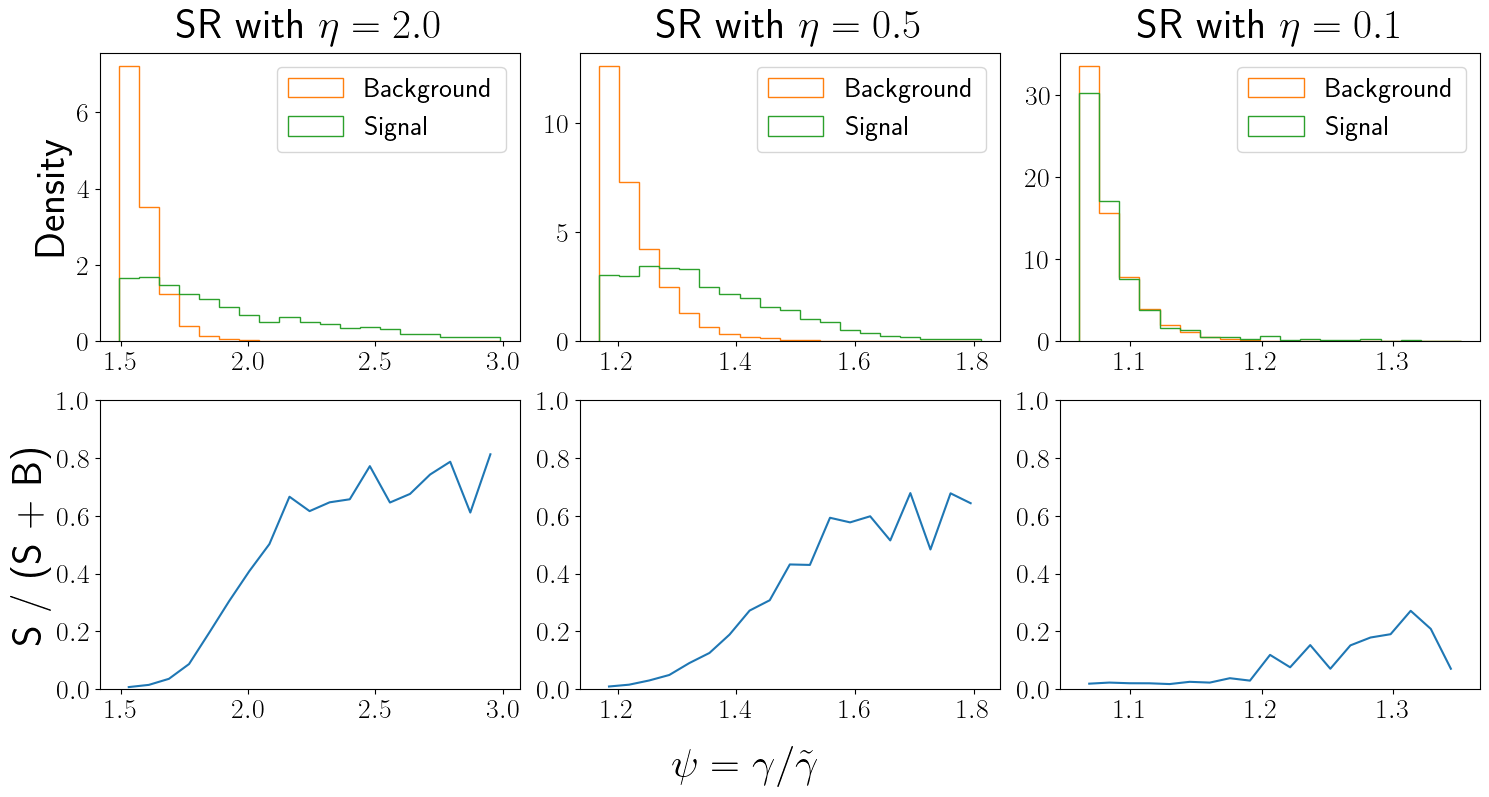

In [8]:
import matplotlib.gridspec as gridspec

SIGNAL_RATIO = 0.01
allowed_noise_scales = [0.1, 0.5, 2.0]

plt.rcParams["axes.labelsize"] = 30
plt.rcParams["axes.titlesize"] = 30
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["axes.titlepad"] = 10
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["figure.labelsize"] = 30

for seed in [50]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed, allowed_noise_scales)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    hashes = hashes[::-1]
    noise_scales = noise_scales[::-1]
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]

    fig = plt.figure(figsize=(5 * len(allowed_noise_scales), 8))  

    # Build a GridSpec with 4 rows and len(allowed_noise_scales) columns
    gs = gridspec.GridSpec(
        2, len(allowed_noise_scales), 
        height_ratios=[1, 1],  # 2:1:2:1 row ratio
        figure=fig
    )

    axs = np.empty((2, len(allowed_noise_scales)), dtype=object)
    for i in range(2):
        for j in range(len(allowed_noise_scales)):
            axs[i, j] = fig.add_subplot(gs[i, j])
    
    
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        noise_scale = get_noise_scales([hash_])[0]
        plot_hash_results_v4(hash_, events_train, events_tst, axs, i)
        title = rf"SR with $\eta = {noise_scale}$" if noise_scale != np.inf else r"SR with $\eta = \infty$"
        axs[0, i].set_title(title)
        
    axs[0, 0].set_ylabel("Density")
    axs[1, 0].set_ylabel("S / (S + B)")
    
    fig.supxlabel(r"$\psi = \gamma / \tilde{\gamma}$")
    
    # Display results
    fig.tight_layout()
    plt.savefig(f"./figures/smearing_and_tails_signal_ratio_{SIGNAL_RATIO}_seed_{seed}.pdf", dpi=300)
    plt.show()